In [1]:
import os

import psycopg
import pandas as pd
import mlflow
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import make_scorer, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score


TABLE_NAME = 'users_churn'
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = 'churn_troston'
RUN_NAME = "feature_selection"
REGISTRY_MODEL_NAME = 'churn_model_troston'
FS_ASSETS = "fs_assets"

In [2]:
df = pd.read_csv('cleaned_churn_df.csv')
COLS_TO_DROP = ["Unnamed: 0", "id", "customer_id",'begin_date']
df = df.drop(columns=COLS_TO_DROP)


In [3]:
BINARY_COLS = [
    "paperless_billing",   # Yes / No
    "online_security",     # Yes / No
    "online_backup",       # Yes / No
    "device_protection",   # Yes / No
    "tech_support",        # Yes / No
    "streaming_tv",        # Yes / No
    "streaming_movies",    # Yes / No
    "gender",              # Male / Female
    "partner",             # Yes / No
    "dependents",          # Yes / No
    "multiple_lines",      # Yes / No
    "internet_service",    # DSL / Fiber optic
]
 
MULTICLASS_COLS = [
    "type",             # Month-to-month / One year / Two year
    "payment_method",   # 4 варианта оплаты
]
 
NUMERIC_COLS = [
    "monthly_charges",
    "total_charges",
    "senior_citizen"
]
 

 
BINARY_MAP = {"Yes": 1, "No": 0, "Female": 1, "Male": 0, "Fiber optic": 1, "DSL": 0}
 
for col in BINARY_COLS:
    df[col] = df[col].map(BINARY_MAP)
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [4]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = encoder.fit_transform(df[MULTICLASS_COLS])
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out())
# new_df = pd.concat([df[['target']], encoded_df], axis=1)

df = pd.concat([df.drop(columns=MULTICLASS_COLS,axis=1), encoded_df],axis=1)
df

,paperless_billing,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,...,senior_citizen,partner,dependents,multiple_lines,target,type_One year,type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,56.95,1889.50,0,1,0,1,0,0,0,...,0,0,0,0,0,1.0,0.0,0.0,0.0,1.0
1,1,53.85,108.15,0,1,1,0,0,0,0,...,0,0,0,0,1,0.0,0.0,0.0,0.0,1.0
2,1,70.70,151.65,1,0,0,0,0,0,0,...,0,0,0,0,1,0.0,0.0,0.0,1.0,0.0
3,1,99.65,820.50,1,0,0,1,0,1,1,...,0,0,0,1,1,0.0,0.0,0.0,1.0,0.0
4,1,89.10,1949.40,1,0,1,0,0,1,0,...,0,0,1,1,0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,1,78.70,1495.10,1,0,0,0,0,1,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
4828,1,84.80,1990.50,0,1,0,1,1,1,1,...,0,1,1,1,0,1.0,0.0,0.0,0.0,1.0
4829,1,103.20,7362.90,1,0,1,1,0,1,1,...,0,1,1,1,0,1.0,0.0,1.0,0.0,0.0
4830,1,74.40,306.60,1,0,0,0,0,0,0,...,1,1,0,1,1,0.0,0.0,0.0,0.0,1.0


In [5]:
df.to_csv('processed_churn.csv')

In [6]:
X = df.drop(columns=['target'])
y = df['target']

In [7]:
X

,paperless_billing,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,type_One year,type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,56.95,1889.50,0,1,0,1,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,1.0
1,1,53.85,108.15,0,1,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0
2,1,70.70,151.65,1,0,0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,1.0,0.0
3,1,99.65,820.50,1,0,0,1,0,1,1,1,0,0,0,1,0.0,0.0,0.0,1.0,0.0
4,1,89.10,1949.40,1,0,1,0,0,1,0,0,0,0,1,1,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,1,78.70,1495.10,1,0,0,0,0,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
4828,1,84.80,1990.50,0,1,0,1,1,1,1,0,0,1,1,1,1.0,0.0,0.0,0.0,1.0
4829,1,103.20,7362.90,1,0,1,1,0,1,1,1,0,1,1,1,1.0,0.0,1.0,0.0,0.0
4830,1,74.40,306.60,1,0,0,0,0,0,0,0,1,1,0,1,0.0,0.0,0.0,0.0,1.0


In [8]:
y

0       0
1       1
2       1
3       1
4       0
       ..
4827    0
4828    0
4829    0
4830    1
4831    0
Name: target, Length: 4832, dtype: int64

In [9]:
X_train_features,X_test_features,y_train,y_test =train_test_split(X,y,random_state=42,test_size=0.2)

In [10]:
y_train

2574    1
4428    0
2225    0
535     1
3918    0
       ..
4426    0
466     1
3092    1
3772    0
860     1
Name: target, Length: 3865, dtype: int64

In [11]:
estimator = RandomForestClassifier(n_estimators=100, n_jobs=-1,random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorer = make_scorer(roc_auc_score, needs_proba=True)


sfs = SFS(estimator, k_features=10, forward=True, floating=False, scoring='roc_auc', cv=cv, n_jobs=-1)

sbs = SFS(estimator, k_features=10, forward=False, floating=False, scoring='roc_auc', cv=cv, n_jobs=-1)

sfs = sfs.fit(X_train_features, y_train)
sbs = sbs.fit(X_train_features, y_train)

# Имена отобранных признаков
top_sfs = sfs.k_feature_names_
top_sbs = sbs.k_feature_names_

In [12]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T 

In [14]:


sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv")

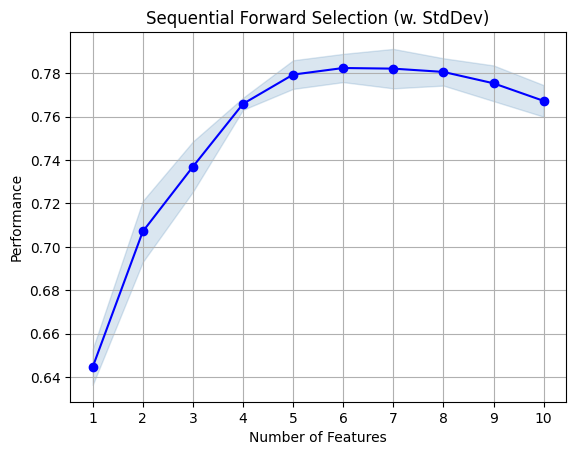

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig("fs_assets/sfs.png")

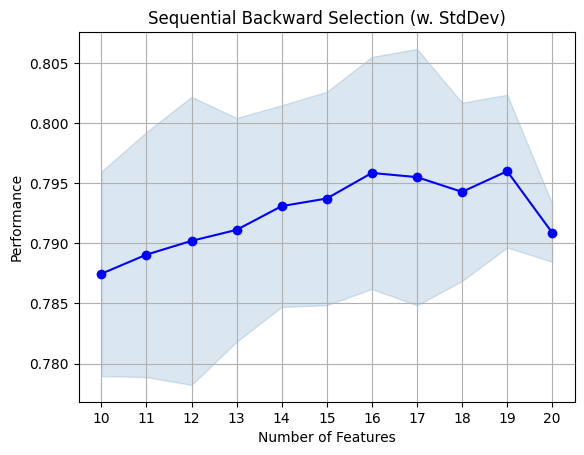

<Figure size 640x480 with 0 Axes>

In [16]:

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig("fs_assets/sbs.png")

In [17]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

In [18]:
interc_features

['online_backup',
 'type_One year',
 'streaming_tv',
 'type_Two year',
 'paperless_billing',
 'online_security']

In [19]:
union_features


['online_backup',
 'tech_support',
 'total_charges',
 'payment_method_Credit card (automatic)',
 'type_One year',
 'payment_method_Electronic check',
 'type_Two year',
 'paperless_billing',
 'senior_citizen',
 'payment_method_Mailed check',
 'monthly_charges',
 'internet_service',
 'streaming_tv',
 'online_security']

In [20]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_and_union", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
   
    mlflow.log_artifacts(FS_ASSETS)

# Теперь обучим две версии модели на двух наборах признаков и сравним метрики.

In [21]:
X_tr_interc, X_test_interc = X_train_features[interc_features], X_test_features[interc_features]
X_tr_uni, X_test_uni = X_train_features[union_features], X_test_features[union_features]


In [22]:
y_train

2574    1
4428    0
2225    0
535     1
3918    0
       ..
4426    0
466     1
3092    1
3772    0
860     1
Name: target, Length: 3865, dtype: int64

In [23]:
model_interc = CatBoostClassifier().fit(X_tr_interc, y_train)
model_union = CatBoostClassifier().fit(X_tr_uni, y_train)

Learning rate set to 0.01835
0:	learn: 0.6858297	total: 60.4ms	remaining: 1m
1:	learn: 0.6781246	total: 61.9ms	remaining: 30.9s
2:	learn: 0.6704805	total: 63.1ms	remaining: 21s
3:	learn: 0.6641714	total: 64ms	remaining: 15.9s
4:	learn: 0.6581509	total: 64.9ms	remaining: 12.9s
5:	learn: 0.6524153	total: 65.8ms	remaining: 10.9s
6:	learn: 0.6488131	total: 66.7ms	remaining: 9.46s
7:	learn: 0.6428163	total: 67.9ms	remaining: 8.42s
8:	learn: 0.6381760	total: 68.9ms	remaining: 7.58s
9:	learn: 0.6331750	total: 69.9ms	remaining: 6.92s
10:	learn: 0.6285701	total: 70.9ms	remaining: 6.37s
11:	learn: 0.6236040	total: 72ms	remaining: 5.93s
12:	learn: 0.6188969	total: 73.1ms	remaining: 5.55s
13:	learn: 0.6146585	total: 74.1ms	remaining: 5.22s
14:	learn: 0.6112754	total: 75.1ms	remaining: 4.93s
15:	learn: 0.6074558	total: 76.1ms	remaining: 4.68s
16:	learn: 0.6045359	total: 77.2ms	remaining: 4.46s
17:	learn: 0.6007226	total: 78.3ms	remaining: 4.27s
18:	learn: 0.5980617	total: 79.3ms	remaining: 4.09s
19

In [24]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

In [26]:
REGISTRY_MODEL_NAME = 'intercepted_features_troston_model'
EXPERIMENT_NAME = 'feature_selection_intersect'

pip_requirements= "requirements.txt"
inter_prediction = model_interc.predict(X_test_interc)
inter_prob = model_interc.predict_proba(X_test_interc)[:,1]
signature = mlflow.models.infer_signature(X_test_interc, inter_prediction)
input_example = X_test_interc[:10]
metadata = {'model_type': 'monthly'}
metrics = {
        "roc_auc":   roc_auc_score(y_test, inter_prob),
        "precision": precision_score(y_test, inter_prediction),
        "recall":    recall_score(y_test, inter_prediction),
        "f1":        f1_score(y_test, inter_prediction),
        "accuracy":  accuracy_score(y_test, inter_prediction)}


experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    
    mlflow.log_metrics(metrics)

 
    mlflow.log_params(model_interc.get_params())


    model_info = mlflow.catboost.log_model(
        cb_model=model_interc,
        artifact_path='models',
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        await_registration_for=60,

        registered_model_name=REGISTRY_MODEL_NAME,
    )


/home/mle-user/mle-mlflow-1/.venv/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
Successfully registered model 'intercepted_features_troston_model'.
2026/04/18 16:25:52 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for 

In [27]:
run_id

'9beafd99888245b18c89d79ef61a3ec3'

In [30]:
REGISTRY_MODEL_NAME = 'united_features_troston_model'
EXPERIMENT_NAME = 'feature_selection_unity'

pip_requirements= "requirements.txt"
uni_prediction = model_union.predict(X_test_uni)
uni_prob = model_union.predict_proba(X_test_uni)[:,1]
signature = mlflow.models.infer_signature(X_test_uni, uni_prediction)
input_example = X_test_uni[:10]
metadata = {'model_type': 'monthly'}
metrics = {
        "roc_auc":   roc_auc_score(y_test, uni_prob),
        "precision": precision_score(y_test, uni_prediction),
        "recall":    recall_score(y_test, uni_prediction),
        "f1":        f1_score(y_test, uni_prediction),
        "accuracy":  accuracy_score(y_test, uni_prediction)}


experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    
    mlflow.log_metrics(metrics)

 
    mlflow.log_params(model_interc.get_params())


    model_info = mlflow.catboost.log_model(
        cb_model=model_union,
        artifact_path='models',
        pip_requirements=pip_requirements,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        await_registration_for=60,

        registered_model_name=REGISTRY_MODEL_NAME,
    )


/home/mle-user/mle-mlflow-1/.venv/lib/python3.10/site-packages/mlflow/models/signature.py:212: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input) if model_input is not None else None
Successfully registered model 'united_features_troston_model'.
2026/04/18 16:29:29 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model

In [31]:
run_id

'39c49ecb8acc47ab99cf79ef39c6e037'